# Experiment 1 — champion-level statistical analysis (LGD)

The full **all-learner** pairwise analysis lives in `Experiment1.2-PD-Stat` / `Experiment1.5-LGD-Stat`. Here we zoom in on **one champion per model family** to answer the paper's actual question — *is the tabular foundation model competitive with the established approaches?* — with far more statistical power and a cleaner interpretation.

**Champions (fixed a priori, one per family):**
- **TabPFN-3** — strongest tabular foundation model.
- **CatBoost** — strongest gradient-boosting model.
- **TabM** — strongest deep-tabular model for regression.
- **Linear Regression** — the regulatory / industry-standard credit baseline.

They are chosen by their **established standing, not by their score on these datasets**, and the complete all-learner analysis stays in the `-Stat` notebook — so this focused view is a *confirmatory companion*, not cherry-picking.

**Methodology.** Every test uses **N = number of datasets** (one five-fold-averaged score per dataset; folds feed only PAMA / variance, never as independent observations). The control-method analysis (§4) uses **TabPFN-3 as the control**.

> **Small-sample caveat.** With only 7 LGD datasets the frequentist tests are low-powered — read them together with the **Bayesian** analysis (§7), which is built for small N.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import apply_style, reset_figure_dir, load_summary
from src.methods.method_config import FOUNDATION_METHODS
from src.methods.method_names import display_name
from src.utils import statistical_testing as st
apply_style()

RESULTS_ROOT = results_root()
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1' / 'lgd_family')
FND = sorted(FOUNDATION_METHODS)

METRIC    = 'R2'
CONTROL   = 'tabpfn_v3'
CHAMPIONS = ['tabpfn_v3', 'catboost', 'tabm', 'LinearRegression']
print('champions:', [display_name(m) for m in CHAMPIONS])

champions: ['TabPFN-3', 'CatBoost', 'TabM', 'Linear Regression']


In [2]:
df       = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', hpo_mode='HPO')
df_folds = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False, hpo_mode='HPO')

# Restrict to the family champions. Data stays on the raw registry keys;
# only the figure labels are mapped to the standard display names.
present = set(df['method'].unique())
champs  = [m for m in CHAMPIONS if m in present]
missing = [m for m in CHAMPIONS if m not in present]
if missing:
    print('WARNING — champions absent from the results:', missing)
df_c    = df[df['method'].isin(champs)]
folds_c = df_folds[df_folds['method'].isin(champs)]
mat     = st.metric_matrix(df_c, METRIC)
mat     = mat[[m for m in champs if m in mat.columns]]   # enforce champion order
ranks   = st.average_ranks(mat)                          # best-first, reused below
print(f'{METRIC}: {mat.shape[1]} champions x {mat.shape[0]} datasets')
display(mat.round(4))

R2: 4 champions x 7 datasets


method,tabpfn_v3,catboost,tabm,LinearRegression
dataset,,,,
0001.heloc,0.8218,0.5162,0.5374,0.2863
0002.loss2,0.7243,0.6558,0.6499,0.5237
0003.axa,0.2112,0.2025,0.1604,0.1922
0004.base_model,0.1916,0.1655,0.1440,0.1000
0005.base_modelisation,0.6392,0.4276,0.3544,0.3436
0006.lgd_freddie,0.4033,0.3680,0.3726,0.2303
0007.lgd_lendingclub,0.7647,0.7450,0.7252,0.6950


## 1. PAMA — how often is each champion the single best?

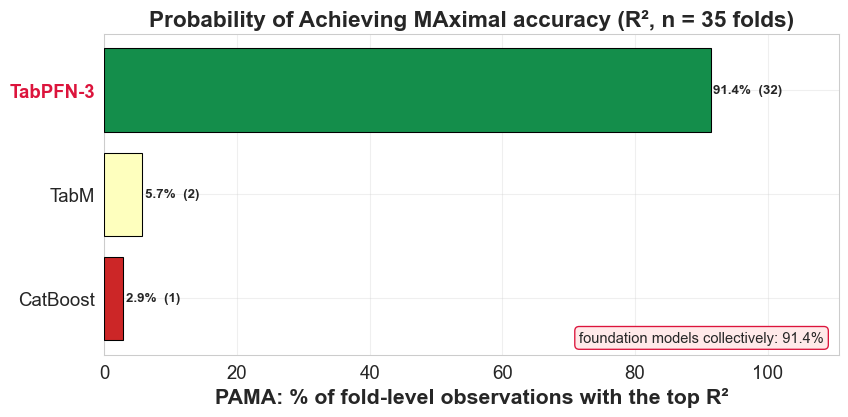

,wins,n_folds,PAMA_%
method,,,
tabpfn_v3,32,35,91.428571
tabm,2,35,5.714286
catboost,1,35,2.857143
LinearRegression,0,35,0.000000


In [3]:
st.plot_pama_bars(folds_c, METRIC, metric_name=METRIC, foundation_methods=FND,
                  out_path=FIGURES_DIR / 'lgd_pama.pdf')
display(st.pama_fold_level(folds_c, METRIC))

## 2. Do the champions differ at all? — omnibus tests

Friedman + Iman–Davenport, plus the more powerful Friedman-Aligned-Ranks and Quade alternatives. All use N = datasets.

In [4]:
f = st.friedman_test(mat)
print(f"N={f['N']} datasets, k={f['k']} champions")
print(f"Friedman/Iman-Davenport: F_F = {f['iman_davenport_F']:.2f}, p = {f['p_iman_davenport']:.3g}")
fa = st.friedman_aligned_ranks_test(mat); qu = st.quade_test(mat)
print(f"Aligned Ranks: chi2 = {fa['aligned_ranks_chi2']:.1f}, p = {fa['p']:.3g}")
print(f"Quade:         F   = {qu['quade_F']:.2f}, p = {qu['p']:.3g}")

N=7 datasets, k=4 champions
Friedman/Iman-Davenport: F_F = 34.83, p = 1.05e-07
Aligned Ranks: chi2 = 16.6, p = 0.000874
Quade:         F   = 14.56, p = 4.65e-05


## 3. The ranking, visually — critical-difference diagram

With only a handful of champions the Nemenyi CD is narrow, so the diagram can actually separate them. Champions joined by a bar are statistically indistinguishable.

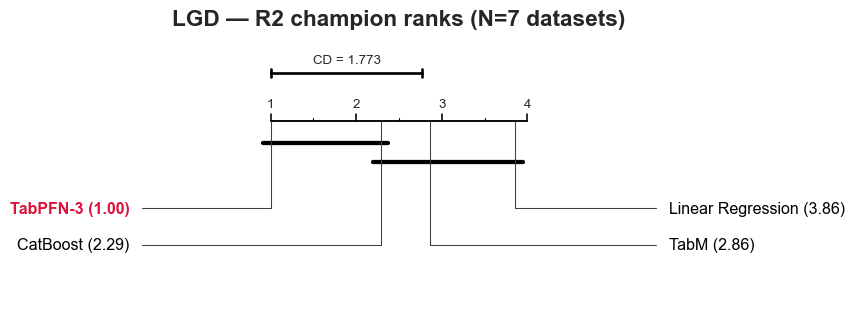

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_family/lgd_cd_r2.pdf')

In [5]:
st.plot_cd_diagram(ranks, st.nemenyi_cd(mat.shape[1], mat.shape[0]),
                   title=f'LGD — {METRIC} champion ranks (N={mat.shape[0]} datasets)',
                   out_path=FIGURES_DIR / 'lgd_cd_r2.pdf')

## 4. Is the foundation model the best? — TabPFN-3 as control

A **control-method** design (Demšar §3.2.3): instead of all pairs, every champion is compared **only against TabPFN-3**. This is the most powerful, most on-topic test — it directly answers *is the TFM significantly better than each established approach?* The Bonferroni–Dunn critical difference is the rank gap a champion must exceed to differ from the control; the table gives the adjusted p-values (several step procedures).

In [6]:
cd_bd = st.bonferroni_dunn_cd(mat.shape[1], mat.shape[0])
print(f'Bonferroni-Dunn CD vs control ({display_name(CONTROL)}): {cd_bd:.3f}')
print('A champion differs from the control iff its mean-rank gap exceeds this.')
ctrl = st.control_apv_table(mat, control=CONTROL)
display(st.format_apv_table(ctrl[['control', 'method', 'p_unadjusted',
                                   'bonferroni_dunn', 'holm', 'finner']]))

Bonferroni-Dunn CD vs control (TabPFN-3): 1.652
A champion differs from the control iff its mean-rank gap exceeds this.


,control,method,p_unadjusted,bonferroni_dunn,holm,finner
0,tabpfn_v3,LinearRegression,0.0000,0.0001,0.0001,0.0001
1,tabpfn_v3,tabm,0.0071,0.0214,0.0142,0.0107
2,tabpfn_v3,catboost,0.0624,0.1873,0.0624,0.0624


## 5. Every head-to-head — Win/Loss matrix

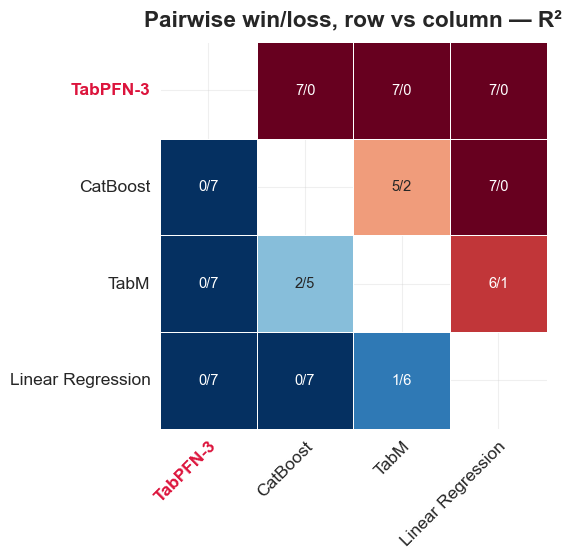

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_family/lgd_winloss.pdf')

In [7]:
st.plot_wilcoxon_wl_matrix_compact(mat, metric_name=METRIC,
                                   out_path=FIGURES_DIR / 'lgd_winloss.pdf')

## 6. Which differences are significant? — Wilcoxon & t-test (Holm) + adjusted-p matrix

Significant pairwise differences in R² (Wilcoxon signed-rank, Holm-corrected, alpha = 0.05):
  0 of 6 pairs significant.

  (none reach significance after Holm correction)
Significant pairwise differences in R² (paired t-test, Holm-corrected, alpha = 0.05):
  0 of 6 pairs significant.

  (none reach significance after Holm correction)


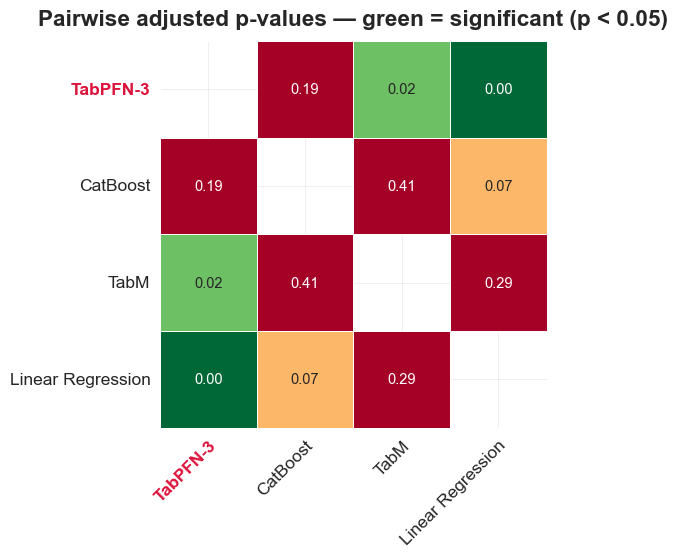

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_family/lgd_significance.pdf')

In [8]:
st.significant_pairs_text(mat, test='wilcoxon', metric_name=METRIC)
st.significant_pairs_text(mat, test='ttest', metric_name=METRIC)
apv = st.pairwise_apv_table(mat)
st.plot_significance_matrix_compact(apv, mat.columns, order=list(ranks.index),
                                    out_path=FIGURES_DIR / 'lgd_significance.pdf')

## 7. The practical question — Bayesian signed-rank with a ROPE

For each champion, the probability that **TabPFN-3** is better / practically equivalent (ROPE = ±0.01) / worse (Benavoli et al., 2017). No significance threshold — ideal for this small number of datasets.

In [9]:
for m in [x for x in champs if x != CONTROL]:
    r = st.bayesian_signed_rank_test(mat[CONTROL], mat[m], rope=0.01)
    print(f'{display_name(CONTROL):12s} vs {display_name(m):22s}:  '
          f'P({display_name(CONTROL)} better)={r["P_right"]:.3f}  '
          f'P(equivalent)={r["P_rope"]:.3f}  P({display_name(m)} better)={r["P_left"]:.3f}')

TabPFN-3     vs CatBoost              :  P(TabPFN-3 better)=0.925  P(equivalent)=0.075  P(CatBoost better)=0.000
TabPFN-3     vs TabM                  :  P(TabPFN-3 better)=0.988  P(equivalent)=0.012  P(TabM better)=0.000
TabPFN-3     vs Linear Regression     :  P(TabPFN-3 better)=0.973  P(equivalent)=0.027  P(Linear Regression better)=0.000


> **The story in one line.** PAMA shows who wins most often; the omnibus tests confirm the champions genuinely differ; the CD diagram and Win/Loss matrix show *who* and *by how much*; the **control-method** test answers whether TabPFN-3 beats each established approach; and the **Bayesian ROPE** analysis turns that into a practical probability of superiority — across only the methods a practitioner would actually consider.

## 8. Summary — copy-paste report

A single plain-text dump of the champion-level analysis, ready to paste into another tool.

In [10]:
st.statistical_report(df_c, folds_c, metric=METRIC, task_name='LGD champions',
                      higher_is_better=True, focus=CHAMPIONS)

STATISTICAL SUMMARY — LGD champions R²  (7 datasets x 4 methods; higher is better; alpha = 0.05)

[1] PAMA — probability of achieving the maximal score (% of (dataset, fold) observations where the method is the single best):
      tabpfn_v3             91.4%   (32/35)
      tabm                   5.7%   (2/35)
      catboost               2.9%   (1/35)
      LinearRegression       0.0%   (0/35)

[2] Average ranks across datasets (1 = best, lower is better):
      tabpfn_v3             1.00
      catboost              2.29
      tabm                  2.86
      LinearRegression      3.86

[3] Friedman omnibus (Iman-Davenport): F_F = 34.833, p = 1.05e-07  ->  REJECT H0 -> methods differ.
[4] More powerful omnibus alternatives: Friedman Aligned Ranks chi2 = 16.55, p = 0.000874;  Quade F = 14.559, p = 4.65e-05.
[5] Nemenyi critical difference (alpha = 0.05): CD = 1.773 (two methods differ significantly iff their mean ranks differ by more than CD).

[6a] Significant pairwise differences — W

"==============================================================================\nSTATISTICAL SUMMARY — LGD champions R²  (7 datasets x 4 methods; higher is better; alpha = 0.05)\n==============================================================================\n\n[1] PAMA — probability of achieving the maximal score (% of (dataset, fold) observations where the method is the single best):\n      tabpfn_v3             91.4%   (32/35)\n      tabm                   5.7%   (2/35)\n      catboost               2.9%   (1/35)\n      LinearRegression       0.0%   (0/35)\n\n[2] Average ranks across datasets (1 = best, lower is better):\n      tabpfn_v3             1.00\n      catboost              2.29\n      tabm                  2.86\n      LinearRegression      3.86\n\n[3] Friedman omnibus (Iman-Davenport): F_F = 34.833, p = 1.05e-07  ->  REJECT H0 -> methods differ.\n[4] More powerful omnibus alternatives: Friedman Aligned Ranks chi2 = 16.55, p = 0.000874;  Quade F = 14.559, p = 4.65e-05.\n[5] 